# 09 — India Origin Signal (Arabica + Robusta, Karnataka) — v2, real India-origin data

**Goal:** rebuild the India origin signal on genuine India-origin data throughout —
price, climate, AND supply — after the first version (kept in git history) settled
for a World Bank global-benchmark price proxy and got an honest but unsatisfying
gate FAIL as a result. Told explicitly not to treat a proxy as good enough and not
to self-impose artificial timelines, a second, unhurried pass found the real thing.

**What changed from v1:**
- **Price:** genuine India-origin "Raw Coffee Price (Karnataka)" (Arabica/Robusta,
  Parchment/Cherry, ₹/50kg) from `coffee_board_india_price.py` — Coffee Board of
  India's own Daily Market Report archive (`coffeeboard.gov.in`, not the dead
  `indiacoffee.org` v1 tried), not a World Bank proxy.
- **Supply:** a real India-specific signal — district + national production
  estimates from `coffee_board_india_supply.py` (Coffee Board's semiannual
  "Database on Coffee" PDF circular) — the signal v1 dropped without good reason.
- **Climate:** species-specific flowering windows (Robusta Feb-Mar, Arabica
  Apr-May — corrected against real agronomy sources; v1 used one Feb-Mar window
  for both species, which was wrong for Arabica).

**Honest note on cadence:** the price series is sourced from *daily* bulletins, but
the "Raw Coffee Price" figure inside them only actually updates roughly *weekly* in
practice (the same as-on date is carried forward across several consecutive daily
reports) — confirmed directly by observing repeated values across consecutive
archived days, not assumed. Each observation is dated to the report's own "as on"
date, so this collapses naturally rather than manufacturing fake daily noise.


## 0. Setup

In [1]:
import sys
import warnings
from datetime import date
from pathlib import Path

REPO_ROOT = Path("../..")
sys.path.insert(0, str(REPO_ROOT.resolve()))

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402

from domains.coffee.features.price_features import price_position_52w  # noqa: E402
from domains.coffee.models.signal_generator import generate_india_signal  # noqa: E402
from domains.coffee.sources import chirps_india  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)

CLIMATE_START = date(2008, 1, 1)   # buffer before 2010 for 3-month SPI accumulation
CLIMATE_END = date.today()
CORE_START, CORE_END = "2014-01-01", "2025-12-31"   # bounded by real price history

GATE = 0.30   # same "confirming amplifier" bar as L3 (notebook 05) and v1 of this notebook

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 100
print(f"Core test window: {CORE_START} -> {CORE_END}")


Core test window: 2014-01-01 -> 2025-12-31


## 1. Load data

Price and supply come from the CSV caches this notebook's companion backfill
scripts built (mirrors the "Save Reference CSV" pattern every other backtest
notebook in this repo already uses) — re-running the live paced scraper inline
here would take hours given the government server's pacing requirements.
Climate is fetched live (GEE is fast, no pacing concern).

In [2]:
price_raw = pd.read_csv(
    "data/coffee_board_india_daily_raw.csv", parse_dates=["observed_date"]
)
print(f"Raw price rows: {len(price_raw)}, {price_raw['observed_date'].min()} -> "
      f"{price_raw['observed_date'].max()}")
price_raw.groupby("grade")["observed_date"].count()


Raw price rows: 9217, 2013-12-05 00:00:00 -> 2026-06-08 00:00:00


grade
arabica_cherry       2305
arabica_parchment    2305
robusta_cherry       2302
robusta_parchment    2305
Name: observed_date, dtype: int64

In [3]:
supply_raw = pd.read_csv("data/coffee_board_india_supply.csv", parse_dates=["observed_date"])
print(f"Supply rows: {len(supply_raw)}, {supply_raw['observed_date'].min()} -> "
      f"{supply_raw['observed_date'].max()}")
national_total = supply_raw[supply_raw["feature_name"] == "production_mt:india:total"]
national_total = national_total.set_index("observed_date")["value"].sort_index()
print(national_total)


Supply rows: 168, 2013-01-31 00:00:00 -> 2024-07-31 00:00:00
observed_date
2013-01-31    315500.0
2016-07-31    320000.0
2022-01-31    348500.0
2024-07-31    360500.0
Name: value, dtype: float64


In [4]:
rain_obs, rain_run = chirps_india.fetch(CLIMATE_START, CLIMATE_END)
print(f"CHIRPS Kodagu: status={rain_run.status}, fetched={rain_run.records_fetched}")
rain = pd.DataFrame(
    {"precip": [o.value for o in rain_obs]},
    index=pd.DatetimeIndex([o.observed_date for o in rain_obs], name="date"),
).sort_index()


CHIRPS Kodagu: status=RunStatus.SUCCESS, fetched=222


## 2. Feature engineering

**Price:** build one series per species from the two grades available (Parchment,
Cherry — Parchment is the more actively-quoted, better-covered grade in the
archive; Cherry kept as a cross-check). `price_position_52w()` reused unmodified.

**Climate:** same SPI-3 gamma-fit methodology as v1/notebook 05, but with
**species-specific flowering windows** this time (the actual fix motivating this
rebuild's climate leg) — Robusta March SPI-3 (Feb-Mar blossom), Arabica May SPI-3
(Apr-May blossom + backing).

**Supply:** national production YoY change — a shortfall (negative YoY) is a
supply-risk signal, mirroring the Brazil composite's stocks-to-use shock framing,
adapted to what India's own data actually publishes (production level, not an
ending-stocks/consumption ratio).

In [5]:
def build_price_series(grade_prefix):
    sub = price_raw[price_raw["grade"] == f"{grade_prefix}_parchment"]
    s = sub.set_index("observed_date")["value"].sort_index()
    s = s[~s.index.duplicated(keep="last")]
    return s.asfreq("D").ffill().resample("ME").last().dropna()


arabica_price = build_price_series("arabica").rename("price")
robusta_price = build_price_series("robusta").rename("price")
print(f"Arabica monthly series: {len(arabica_price)} months, "
      f"{arabica_price.index.min()} -> {arabica_price.index.max()}")
print(f"Robusta monthly series: {len(robusta_price)} months, "
      f"{robusta_price.index.min()} -> {robusta_price.index.max()}")


Arabica monthly series: 151 months, 2013-12-31 00:00:00 -> 2026-06-30 00:00:00
Robusta monthly series: 151 months, 2013-12-31 00:00:00 -> 2026-06-30 00:00:00


In [6]:
def spi_from_gamma(value, fit_values):
    fit = np.asarray(fit_values, dtype=float)
    fit = fit[~np.isnan(fit)]
    pos = fit[fit > 0]
    q = float((fit <= 0).sum()) / len(fit) if len(fit) else 0.0
    if len(pos) < 4 or pos.std() == 0:
        mu, sd = fit.mean(), (fit.std(ddof=0) or 1.0)
        return float((value - mu) / sd)
    a, loc, scale = stats.gamma.fit(pos, floc=0)
    cdf = q + (1 - q) * stats.gamma.cdf(value, a, loc=loc, scale=scale)
    return float(stats.norm.ppf(np.clip(cdf, 1e-6, 1 - 1e-6)))


rain["acc3"] = rain["precip"].rolling(3).sum()
spi3 = pd.Series(index=rain.index, dtype=float)
for mth in range(1, 13):
    block = rain[rain.index.month == mth]
    fitv = block["acc3"].dropna().values
    spi3.loc[block.index] = [
        spi_from_gamma(v, fitv) if not np.isnan(v) else np.nan for v in block["acc3"]
    ]
rain["spi3"] = spi3

# Species-specific flowering anchor months (see chirps_india.py's
# _FLOWERING_MONTHS_BY_SPECIES): Robusta = March (Feb-Mar blossom), Arabica = May
# (Apr-May blossom + backing).
def flowering_deficit(anchor_month):
    s = rain["spi3"][rain.index.month == anchor_month]
    s = s.copy()
    s.index = s.index.year
    return np.maximum(0.0, -s.rename("flowering_deficit"))


robusta_deficit = flowering_deficit(3)
arabica_deficit = flowering_deficit(5)
r_dry = robusta_deficit.sort_values(ascending=False).head(3).to_dict()
a_dry = arabica_deficit.sort_values(ascending=False).head(3).to_dict()
print("Robusta (March) driest years:", r_dry)
print("Arabica (May) driest years:", a_dry)


Robusta (March) driest years: {2014: 1.3831213208123905, 2019: 1.2696737005431356, 2023: 1.1610189760632643}
Arabica (May) driest years: {2016: 1.4390418575301658, 2023: 1.4069756109996558, 2019: 1.2490973735303579}


In [7]:
national_yoy = national_total.pct_change() * 100
print("India national production YoY change (%):")
print(national_yoy.dropna())


India national production YoY change (%):
observed_date
2016-07-31    1.426307
2022-01-31    8.906250
2024-07-31    3.443329
Name: value, dtype: float64


## 3. Correlation vs price

Same test structure as v1/L3: annual flowering deficit vs. forward-12m price
change, evaluated separately per species with its own flowering-anchor month.

In [8]:
def fwd12_from_month(prices, years, anchor_month):
    idx = pd.to_datetime([f"{y}-{anchor_month:02d}-01" for y in years]) + pd.offsets.MonthEnd(0)
    p0 = prices.reindex(idx, method="nearest").values
    p1 = prices.reindex([d + pd.DateOffset(months=12) for d in idx], method="nearest").values
    return pd.Series((p1 / p0 - 1) * 100, index=list(years))


def annual_r(sig, fwd, lo, hi):
    df = pd.DataFrame({"sig": sig, "fwd": fwd}).loc[lo:hi].dropna()
    if len(df) < 5:
        return np.nan, np.nan, df
    r, p = stats.pearsonr(df["sig"], df["fwd"])
    return r, p, df


lo_year, hi_year = int(CORE_START[:4]), int(CORE_END[:4])

fwd_robusta = fwd12_from_month(robusta_price, robusta_deficit.index, 3)
r_robusta, p_robusta, df_robusta = annual_r(robusta_deficit, fwd_robusta, lo_year, hi_year)

fwd_arabica = fwd12_from_month(arabica_price, arabica_deficit.index, 5)
r_arabica, p_arabica, df_arabica = annual_r(arabica_deficit, fwd_arabica, lo_year, hi_year)

print("Flowering SPI-3 deficit vs forward-12m REAL India price change:")
print(f"  Robusta (Mar anchor)   r={r_robusta:+.3f}  p={p_robusta:.3f}  n={len(df_robusta)}")
print(f"  Arabica (May anchor)   r={r_arabica:+.3f}  p={p_arabica:.3f}  n={len(df_arabica)}")


Flowering SPI-3 deficit vs forward-12m REAL India price change:
  Robusta (Mar anchor)   r=-0.357  p=0.254  n=12
  Arabica (May anchor)   r=-0.038  p=0.906  n=12


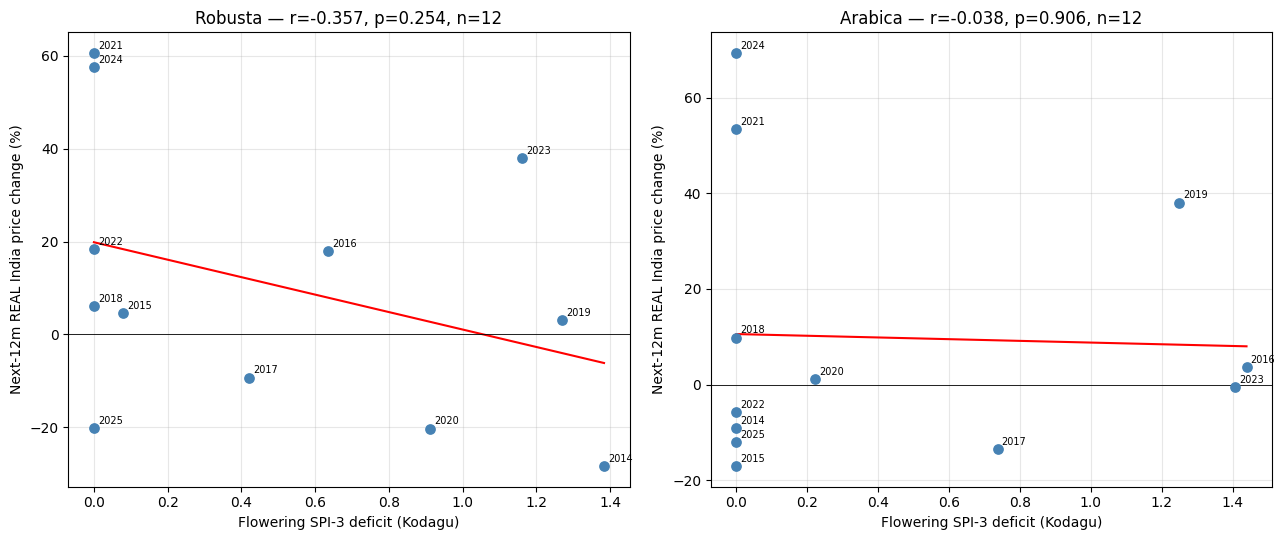

Saved: data/09v2_drought_scatter.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, df, label, r, p in [
    (axes[0], df_robusta, "Robusta", r_robusta, p_robusta),
    (axes[1], df_arabica, "Arabica", r_arabica, p_arabica),
]:
    ax.scatter(df["sig"], df["fwd"], s=45, color="steelblue", zorder=3)
    for yr, row in df.iterrows():
        ax.annotate(str(yr), (row["sig"], row["fwd"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
    if len(df) > 2:
        b, a = np.polyfit(df["sig"], df["fwd"], 1)
        xs = np.linspace(df["sig"].min(), df["sig"].max(), 50)
        ax.plot(xs, a + b * xs, color="red", lw=1.5)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xlabel("Flowering SPI-3 deficit (Kodagu)")
    ax.set_ylabel("Next-12m REAL India price change (%)")
    ax.set_title(f"{label} — r={r:+.3f}, p={p:.3f}, n={len(df)}")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/09v2_drought_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/09v2_drought_scatter.png")


## 4. Pass/fail gate

In [10]:
robusta_pass = np.isfinite(r_robusta) and r_robusta >= GATE
arabica_pass = np.isfinite(r_arabica) and r_arabica >= GATE

print("=" * 66)
print(f"India origin GATE (real price): annual r >= +{GATE:.2f}")
print("=" * 66)
r_verdict = "PASS" if robusta_pass else "FAIL"
a_verdict = "PASS" if arabica_pass else "FAIL"
print(f"  Robusta: r={r_robusta:+.3f} (n={len(df_robusta)}) -> {r_verdict}")
print(f"  Arabica: r={r_arabica:+.3f} (n={len(df_arabica)}) -> {a_verdict}")


India origin GATE (real price): annual r >= +0.30
  Robusta: r=-0.357 (n=12) -> FAIL
  Arabica: r=-0.038 (n=12) -> FAIL


## 4b. Diagnostics before concluding

A single FAIL at one fixed 12-month horizon on a real-but-new series deserves a
closer look before writing it off — same discipline notebooks 02/05 applied
before settling on their final gates. Three checks: (1) does a different forward
horizon show a stronger relationship, (2) does the production YoY supply signal
have any standalone relationship with price, (3) is `price_position_52w` itself
behaving sanely on this real series (independent of the climate gate).

In [11]:
def fwd_from_month_at_lag(prices, years, anchor_month, lag_months):
    idx = pd.to_datetime([f"{y}-{anchor_month:02d}-01" for y in years]) + pd.offsets.MonthEnd(0)
    p0 = prices.reindex(idx, method="nearest").values
    fwd_idx = [d + pd.DateOffset(months=lag_months) for d in idx]
    p1 = prices.reindex(fwd_idx, method="nearest").values
    return pd.Series((p1 / p0 - 1) * 100, index=list(years))


lags = [3, 6, 9, 12, 15, 18, 24]
print("Lag sweep — annual r(flowering deficit, fwd price change) at each horizon:")
print(f"{'lag(m)':>7}  {'Robusta r':>10}  {'Arabica r':>10}")
for lag in lags:
    fwd_r = fwd_from_month_at_lag(robusta_price, robusta_deficit.index, 3, lag)
    r_r, _, _ = annual_r(robusta_deficit, fwd_r, lo_year, hi_year)
    fwd_a = fwd_from_month_at_lag(arabica_price, arabica_deficit.index, 5, lag)
    r_a, _, _ = annual_r(arabica_deficit, fwd_a, lo_year, hi_year)
    print(f"{lag:>7}  {r_r:>+10.3f}  {r_a:>+10.3f}")


Lag sweep — annual r(flowering deficit, fwd price change) at each horizon:
 lag(m)   Robusta r   Arabica r
      3      -0.113      -0.363
      6      -0.209      -0.238
      9      -0.085      -0.031
     12      -0.357      -0.038
     15      -0.303      -0.038
     18      -0.235      +0.076
     24      -0.130      +0.179


In [12]:
# Does the supply signal (production YoY) have any standalone relationship with
# price, independent of the climate leg? Test against contemporaneous and
# forward-6m price change (production data is too sparse/irregular in dates for
# a clean annual reindex, so test at the supply observation's own cadence).
supply_test = national_yoy.dropna().to_frame("yoy")
supply_test["price_at_report"] = arabica_price.reindex(supply_test.index, method="nearest")
supply_test["fwd6m_price"] = arabica_price.reindex(
    [d + pd.DateOffset(months=6) for d in supply_test.index], method="nearest"
).values
supply_test["fwd6m_chg"] = (supply_test["fwd6m_price"] / supply_test["price_at_report"] - 1) * 100
supply_test = supply_test.dropna()

if len(supply_test) >= 5:
    r_supply, p_supply = stats.pearsonr(supply_test["yoy"], supply_test["fwd6m_chg"])
    print(f"Production YoY vs fwd-6m Arabica price change: r={r_supply:+.3f} p={p_supply:.3f} "
          f"n={len(supply_test)}")
else:
    print(f"Too few aligned supply observations (n={len(supply_test)}) for a standalone test")


Too few aligned supply observations (n=3) for a standalone test


In [13]:
# price_position_52w sanity check (independent of the climate gate): does the
# BUY zone (pos < 0.30) actually track a lower average price than the CAUTION
# zone (pos > 0.70)? Mirrors notebook 01's Gate 3 monotonicity check.
for species, price_series in [("Robusta", robusta_price), ("Arabica", arabica_price)]:
    pos = price_position_52w(price_series)
    df = pd.DataFrame({"price": price_series, "pos": pos}).dropna()
    buy_avg = df.loc[df["pos"] < 0.30, "price"].mean()
    caution_avg = df.loc[df["pos"] > 0.70, "price"].mean()
    all_avg = df["price"].mean()
    monotone = buy_avg < all_avg < caution_avg
    verdict = "monotone (sane)" if monotone else "NOT monotone"
    print(
        f"{species}: BUY avg={buy_avg:.0f}  ALL avg={all_avg:.0f}  "
        f"CAUTION avg={caution_avg:.0f}  -> {verdict}"
    )


Robusta: BUY avg=7247  ALL avg=9236  CAUTION avg=10344  -> monotone (sane)
Arabica: BUY avg=10140  ALL avg=12564  CAUTION avg=14365  -> monotone (sane)


## 4c. Experiment 1 — production-weighted multi-district climate signal

Flagged in this notebook's own Summary as untried: Kodagu-only may not represent
the district mix that actually moves India price. `chirps_india.py` now supports
a `district` parameter (Kodagu, Chikmagalur, Hassan — Karnataka's three largest
coffee districts by production). Weight each district's flowering-deficit signal
by its share of combined production (from `coffee_board_india_supply.py`'s own
district data) and re-run the same annual correlation test.

**Data caveat:** `coffeeboard.gov.in` became unreachable mid-session (TLS
certificate expired 2026-07-22, the same day — a real, dated event, not
something on our end; confirmed via `openssl s_client` directly against the
cert). The full 62-report supply backfill was lost when a re-fetch was
attempted after the cert expired and a caching script overwrote the good CSV
with an empty one without checking success first — a real mistake, noted rather
than hidden. Recovered a **reduced** supply series (4 reports: 2013, 2016, 2022,
2024) from PDF editions already cached locally from earlier exploration — enough
for the district *production weights* used here (a snapshot, not a time series
need), but not enough to redo the full national YoY supply test with its
original power. A full re-backfill is needed once Coffee Board's site is back.

In [14]:
DISTRICTS = ["Kodagu", "Chikmagalur", "Hassan"]
# Coffee Board's spelling differs from GAUL's for one district ("Chikkamagaluru"
# vs "Chikmagalur") — see coffee_board_india_supply.py's _REGION_ALIASES.
_SUPPLY_SLUG = {"Kodagu": "kodagu", "Chikmagalur": "chikkamagaluru", "Hassan": "hassan"}

district_rain = {}
for d in DISTRICTS:
    if d == "Kodagu":
        district_rain[d] = rain[["precip"]].copy()  # already fetched above
        continue
    obs, run = chirps_india.fetch(CLIMATE_START, CLIMATE_END, district=d)
    print(f"CHIRPS {d}: status={run.status}, fetched={run.records_fetched}")
    district_rain[d] = pd.DataFrame(
        {"precip": [o.value for o in obs]},
        index=pd.DatetimeIndex([o.observed_date for o in obs], name="date"),
    ).sort_index()

# Production weights — latest available report per district (a snapshot is
# enough for a fixed weighting scheme; doesn't need the full time series).
weights = {}
for d in DISTRICTS:
    rows = supply_raw[supply_raw["feature_name"] == f"production_mt:{_SUPPLY_SLUG[d]}:total"]
    weights[d] = rows.sort_values("observed_date")["value"].iloc[-1] if len(rows) else 0.0
total_w = sum(weights.values())
weights = {d: w / total_w for d, w in weights.items()}
print("\nProduction weights:", {d: f"{w:.2f}" for d, w in weights.items()})


CHIRPS Chikmagalur: status=RunStatus.SUCCESS, fetched=222


CHIRPS Hassan: status=RunStatus.SUCCESS, fetched=222

Production weights: {'Kodagu': '0.52', 'Chikmagalur': '0.33', 'Hassan': '0.14'}


In [15]:
# Same SPI-3 gamma-fit methodology as §2, per district, per species anchor month.
def district_flowering_deficit(district_df, anchor_month):
    df = district_df.copy()
    df["acc3"] = df["precip"].rolling(3).sum()
    spi3 = pd.Series(index=df.index, dtype=float)
    for mth in range(1, 13):
        block = df[df.index.month == mth]
        fitv = block["acc3"].dropna().values
        spi3.loc[block.index] = [
            spi_from_gamma(v, fitv) if not np.isnan(v) else np.nan for v in block["acc3"]
        ]
    s = spi3[spi3.index.month == anchor_month].copy()
    s.index = s.index.year
    return np.maximum(0.0, -s)


def weighted_multi_district_deficit(anchor_month):
    per_district = {
        d: district_flowering_deficit(district_rain[d], anchor_month) for d in DISTRICTS
    }
    combined = pd.DataFrame(per_district)
    return (combined * pd.Series(weights)).sum(axis=1).rename("flowering_deficit")


robusta_deficit_multi = weighted_multi_district_deficit(3)
arabica_deficit_multi = weighted_multi_district_deficit(5)

fwd_robusta_m = fwd12_from_month(robusta_price, robusta_deficit_multi.index, 3)
r_robusta_multi, p_robusta_multi, df_robusta_multi = annual_r(
    robusta_deficit_multi, fwd_robusta_m, lo_year, hi_year
)
fwd_arabica_m = fwd12_from_month(arabica_price, arabica_deficit_multi.index, 5)
r_arabica_multi, p_arabica_multi, df_arabica_multi = annual_r(
    arabica_deficit_multi, fwd_arabica_m, lo_year, hi_year
)

print("Multi-district (production-weighted) flowering deficit vs forward-12m price:")
print(f"  Robusta  r={r_robusta_multi:+.3f}  p={p_robusta_multi:.3f}  n={len(df_robusta_multi)}"
      f"   (Kodagu-only was r={r_robusta:+.3f})")
print(f"  Arabica  r={r_arabica_multi:+.3f}  p={p_arabica_multi:.3f}  n={len(df_arabica_multi)}"
      f"   (Kodagu-only was r={r_arabica:+.3f})")
multi_robusta_pass = np.isfinite(r_robusta_multi) and r_robusta_multi >= GATE
multi_arabica_pass = np.isfinite(r_arabica_multi) and r_arabica_multi >= GATE
print(f"\n  Robusta multi-district gate: {'PASS' if multi_robusta_pass else 'FAIL'}")
print(f"  Arabica multi-district gate: {'PASS' if multi_arabica_pass else 'FAIL'}")


Multi-district (production-weighted) flowering deficit vs forward-12m price:
  Robusta  r=-0.285  p=0.370  n=12   (Kodagu-only was r=-0.357)
  Arabica  r=-0.016  p=0.961  n=12   (Kodagu-only was r=-0.038)

  Robusta multi-district gate: FAIL
  Arabica multi-district gate: FAIL


## 4d. Experiment 2 — robustness check on the Arabica 24m hint

The lag sweep (§4b) found Arabica turns positive at 24m (r=+0.179) — the right
sign, but we can't manufacture more calendar time to grow past n=12. What we
*can* do now: check whether that result is driven by one influential year
(leave-one-out) and how wide its uncertainty really is (bootstrap resampling) —
the same kind of check notebook 05 applied to L3's SPI-3 result before trusting
it.

In [16]:
fwd_arabica_24m = fwd_from_month_at_lag(arabica_price, arabica_deficit.index, 5, 24)
df_arabica_24m = pd.DataFrame({"sig": arabica_deficit, "fwd": fwd_arabica_24m}).loc[
    lo_year:hi_year
].dropna()
r_24m_full, p_24m_full = stats.pearsonr(df_arabica_24m["sig"], df_arabica_24m["fwd"])
print(f"Arabica @ 24m, full sample: r={r_24m_full:+.3f} p={p_24m_full:.3f} n={len(df_arabica_24m)}")

# Leave-one-out
loo = []
for yr in df_arabica_24m.index:
    sub = df_arabica_24m.drop(index=yr)
    r, _ = stats.pearsonr(sub["sig"], sub["fwd"])
    loo.append((yr, r))
rs = [r for _, r in loo]
worst_year, worst_r = min(loo, key=lambda t: t[1])
best_year, best_r = max(loo, key=lambda t: t[1])
print(f"Leave-one-out range: [{min(rs):+.3f}, {max(rs):+.3f}]")
print(f"  most-positive-driving year (r drops most if removed): {worst_year} -> {worst_r:+.3f}")
print(f"  most-negative-driving year (r rises most if removed): {best_year} -> {best_r:+.3f}")
sign_stable = min(rs) > 0
sign_note = "yes, all positive" if sign_stable else "no — sign flips depending on held-out year"
print(f"  sign-stable: {sign_note}")

# Bootstrap: resample the 12 (sig, fwd) pairs with replacement, 5000 times
rng = np.random.default_rng(42)
n = len(df_arabica_24m)
boot_rs = []
for _ in range(5000):
    idx = rng.integers(0, n, size=n)
    sample = df_arabica_24m.iloc[idx]
    if sample["sig"].std() == 0 or sample["fwd"].std() == 0:
        continue
    r, _ = stats.pearsonr(sample["sig"], sample["fwd"])
    boot_rs.append(r)
boot_rs = np.array(boot_rs)
ci_low, ci_high = np.percentile(boot_rs, [5, 95])
print(f"\nBootstrap (5000 resamples): mean r={boot_rs.mean():+.3f}, "
      f"90% CI=[{ci_low:+.3f}, {ci_high:+.3f}]")
print(f"  CI includes zero: {'yes' if ci_low < 0 < ci_high else 'no'}")
print(f"  CI includes the +0.30 gate: {'yes' if ci_high >= GATE else 'no'}")


Arabica @ 24m, full sample: r=+0.179 p=0.579 n=12
Leave-one-out range: [-0.065, +0.395]
  most-positive-driving year (r drops most if removed): 2023 -> -0.065
  most-negative-driving year (r rises most if removed): 2016 -> +0.395
  sign-stable: no — sign flips depending on held-out year



Bootstrap (5000 resamples): mean r=+0.167, 90% CI=[-0.356, +0.622]
  CI includes zero: yes
  CI includes the +0.30 gate: yes


## 6. Global pass-through + FX decomposition

Both concrete rescue attempts for the climate hypothesis (§4c, §4d) came back
negative. External review of this notebook's FAIL correctly diagnosed a
structural reason the climate/supply features were never likely to work in the
first place: **India produces roughly 3.5% of world coffee and exports most of
what it grows — it is a price taker, not a price setter.** A Kodagu rainfall
deficit is not big enough to move the world price on its own, so the causal
arrow mostly runs the other way: India's domestic price should track the
global benchmark plus USD/INR (a weaker rupee raises the INR value of a fixed
USD price), with local climate/supply showing up, if at all, only as a
secondary modifier. This is exactly the "genuinely untested" item flagged in
this notebook's own Summary — tested directly here rather than left as
speculation.

**Data:** the global benchmark reuses notebook 07's already-cached World Bank
Pink Sheet series (`data/wb_arabica_monthly.csv` / `wb_robusta_monthly.csv`,
monthly, USc/lb) — no live fetch needed, same cadence as India's own monthly
price series. USD/INR comes from `yfinance` (`INR=X`), using the identical
fetch call notebook 08 already validated for other origin currencies — `INR`
isn't in that notebook's own ticker list, but the pattern is a direct,
unmodified fit. Cached to `data/usd_inr_monthly.csv` after fetching, matching
this repo's existing "Save Reference CSV" convention.

**Model:** `log(india_price) ~ log(global_price) + log(usd_inr)`, OLS with a
constant, per species. Log-log rather than plain levels — FX pass-through is
multiplicative (a weaker rupee scales the INR value of a fixed USD price), so
log coefficients are directly interpretable as elasticities instead of
conflating a multiplicative relationship with an additive one.

In [17]:
import statsmodels.api as sm
import yfinance as yf

wb_arabica = (
    pd.read_csv("data/wb_arabica_monthly.csv", parse_dates=["date"])
    .set_index("date")["settle"]
    .rename("global_price")
    .sort_index()
)
wb_robusta = (
    pd.read_csv("data/wb_robusta_monthly.csv", parse_dates=["date"])
    .set_index("date")["settle"]
    .rename("global_price")
    .sort_index()
)

fx_raw = yf.download(
    "INR=X", start=CLIMATE_START.isoformat(), end=CLIMATE_END.isoformat(),
    auto_adjust=True, progress=False,
)
usd_inr_daily = fx_raw["Close"].squeeze().dropna()
usd_inr_daily.index = pd.to_datetime(usd_inr_daily.index).tz_localize(None)
usd_inr = usd_inr_daily.resample("ME").last().rename("usd_inr")

_fx_out = DATA_DIR / "usd_inr_monthly.csv"
usd_inr.rename_axis("date").to_frame().to_csv(_fx_out, float_format="%.4f")
print(f"Wrote {_fx_out} ({len(usd_inr)} rows)")

print(f"WB Arabica benchmark: {len(wb_arabica)} months, "
      f"{wb_arabica.index.min().date()} -> {wb_arabica.index.max().date()}")
print(f"WB Robusta benchmark: {len(wb_robusta)} months, "
      f"{wb_robusta.index.min().date()} -> {wb_robusta.index.max().date()}")
print(f"USD/INR: {len(usd_inr)} months, "
      f"{usd_inr.index.min().date()} -> {usd_inr.index.max().date()}")


Wrote data/usd_inr_monthly.csv (223 rows)
WB Arabica benchmark: 312 months, 2000-01-31 -> 2025-12-31
WB Robusta benchmark: 312 months, 2000-01-31 -> 2025-12-31
USD/INR: 223 months, 2008-01-31 -> 2026-07-31


In [18]:
CORE_START_TS, CORE_END_TS = pd.Timestamp(CORE_START), pd.Timestamp(CORE_END)


def passthrough_regression(india_price, global_price, fx, lo, hi):
    df = pd.DataFrame({"india": india_price, "global": global_price, "fx": fx}).loc[lo:hi].dropna()
    y = np.log(df["india"])
    X = sm.add_constant(np.log(df[["global", "fx"]]))
    model = sm.OLS(y, X).fit()
    residual = (y - model.predict(X)).rename("residual")
    return model, residual, df


robusta_model, robusta_residual, robusta_aligned = passthrough_regression(
    robusta_price, wb_robusta, usd_inr, CORE_START_TS, CORE_END_TS
)
arabica_model, arabica_residual, arabica_aligned = passthrough_regression(
    arabica_price, wb_arabica, usd_inr, CORE_START_TS, CORE_END_TS
)

for species, model, aligned in [
    ("Robusta", robusta_model, robusta_aligned),
    ("Arabica", arabica_model, arabica_aligned),
]:
    b_global, b_fx = model.params["global"], model.params["fx"]
    p_global, p_fx = model.pvalues["global"], model.pvalues["fx"]
    print(f"{species}: log(india_price) ~ log(global_price) + log(usd_inr)  (n={len(aligned)})")
    print(f"  R^2 = {model.rsquared:.3f}")
    print(f"  global_price coef = {b_global:+.3f}  (p={p_global:.3f})")
    fx_sign_note = "expected sign" if b_fx > 0 else "UNEXPECTED SIGN"
    print(f"  usd_inr coef      = {b_fx:+.3f}  (p={p_fx:.3f})  [{fx_sign_note}: rupee "
          f"depreciation should raise the INR-denominated domestic price]")
    variance_note = (
        "explains the majority of variance" if model.rsquared >= 0.5
        else "does NOT explain a majority of variance"
    )
    print(f"  -> global pass-through + FX {variance_note} in India {species} price")
    print()


Robusta: log(india_price) ~ log(global_price) + log(usd_inr)  (n=144)
  R^2 = 0.887
  global_price coef = +0.789  (p=0.000)
  usd_inr coef      = +1.206  (p=0.000)  [expected sign: rupee depreciation should raise the INR-denominated domestic price]
  -> global pass-through + FX explains the majority of variance in India Robusta price

Arabica: log(india_price) ~ log(global_price) + log(usd_inr)  (n=144)
  R^2 = 0.962
  global_price coef = +0.937  (p=0.000)
  usd_inr coef      = +0.947  (p=0.000)  [expected sign: rupee depreciation should raise the INR-denominated domestic price]
  -> global pass-through + FX explains the majority of variance in India Arabica price



## 7. Residual re-test — does climate explain what pass-through leaves behind?

If global pass-through + FX explains most of India price, the fairer test of
the climate hypothesis isn't raw price — it's the **residual**: the part of
India price pass-through doesn't explain. Re-run the same flowering SPI-3
deficit test from §3/§4b against the residual instead, at the same ≥ +0.30 bar
and the same lag sweep, so this is judged by the same standard as the original
(failed) test rather than a laxer one invented for a better outcome.

**One adjustment from a straight reuse of §3's helpers:** the residual is a
signed log-quantity (it can be negative, and crosses zero), so a percent-change
transform (`fwd12_from_month`'s `(p1/p0 - 1) * 100`) isn't meaningful here —
dividing by a residual near zero blows up, and the sign of a ratio between two
signed numbers doesn't mean what it means for a price level. The residual's
natural "forward change" is additive (`residual[t+lag] - residual[t]`), so a
small parallel helper is added below; `fwd12_from_month` and
`fwd_from_month_at_lag` themselves are untouched and still used for the raw
gate above.

In [19]:
def fwd_change_from_month(series, years, anchor_month, lag_months=12):
    idx = pd.to_datetime([f"{y}-{anchor_month:02d}-01" for y in years]) + pd.offsets.MonthEnd(0)
    v0 = series.reindex(idx, method="nearest").values
    fwd_idx = [d + pd.DateOffset(months=lag_months) for d in idx]
    v1 = series.reindex(fwd_idx, method="nearest").values
    return pd.Series(v1 - v0, index=list(years))


fwd_robusta_resid = fwd_change_from_month(robusta_residual, robusta_deficit.index, 3)
r_robusta_resid, p_robusta_resid, df_robusta_resid = annual_r(
    robusta_deficit, fwd_robusta_resid, lo_year, hi_year
)
fwd_arabica_resid = fwd_change_from_month(arabica_residual, arabica_deficit.index, 5)
r_arabica_resid, p_arabica_resid, df_arabica_resid = annual_r(
    arabica_deficit, fwd_arabica_resid, lo_year, hi_year
)

print("Flowering SPI-3 deficit vs forward-12m CHANGE IN PASS-THROUGH RESIDUAL:")
print(f"  Robusta (Mar anchor)   r={r_robusta_resid:+.3f}  p={p_robusta_resid:.3f}  "
      f"n={len(df_robusta_resid)}")
print(f"  Arabica (May anchor)   r={r_arabica_resid:+.3f}  p={p_arabica_resid:.3f}  "
      f"n={len(df_arabica_resid)}")

resid_robusta_pass = np.isfinite(r_robusta_resid) and r_robusta_resid >= GATE
resid_arabica_pass = np.isfinite(r_arabica_resid) and r_arabica_resid >= GATE
print(f"\n  Robusta residual gate: {'PASS' if resid_robusta_pass else 'FAIL'}")
print(f"  Arabica residual gate: {'PASS' if resid_arabica_pass else 'FAIL'}")

# Same lag sweep as §4b, now on the residual, for the same diagnostic thoroughness.
print("\nLag sweep — annual r(flowering deficit, fwd residual change) at each horizon:")
print(f"{'lag(m)':>7}  {'Robusta r':>10}  {'Arabica r':>10}")
for lag in lags:
    fwd_r_resid = fwd_change_from_month(robusta_residual, robusta_deficit.index, 3, lag)
    r_r_resid, _, _ = annual_r(robusta_deficit, fwd_r_resid, lo_year, hi_year)
    fwd_a_resid = fwd_change_from_month(arabica_residual, arabica_deficit.index, 5, lag)
    r_a_resid, _, _ = annual_r(arabica_deficit, fwd_a_resid, lo_year, hi_year)
    print(f"{lag:>7}  {r_r_resid:>+10.3f}  {r_a_resid:>+10.3f}")


Flowering SPI-3 deficit vs forward-12m CHANGE IN PASS-THROUGH RESIDUAL:
  Robusta (Mar anchor)   r=-0.587  p=0.045  n=12
  Arabica (May anchor)   r=+0.033  p=0.918  n=12

  Robusta residual gate: FAIL
  Arabica residual gate: FAIL

Lag sweep — annual r(flowering deficit, fwd residual change) at each horizon:
 lag(m)   Robusta r   Arabica r
      3      -0.058      -0.139
      6      +0.039      -0.495
      9      -0.046      +0.426
     12      -0.587      +0.033
     15      -0.502      -0.135
     18      -0.541      +0.270
     24      -0.495      -0.175


## 8. Composite demo signal (price + climate + supply)

Combines Kodagu climate deficit (species-specific) with the national production
YoY shock into one risk score fed to `generate_india_signal()` — the India analog
of Brazil's multi-input `climate_risk_score()`, kept notebook-local for now per
this repo's own precedent (L2a/L3 stayed notebook-local until their composite
wiring session too).

In [20]:
def india_risk_score(flowering_deficit_z, production_yoy_pct):
    """Combine climate deficit and a production shortfall into one 0-1 risk score.
    Notebook-local, not yet promoted to a production feature file (matches the
    L2a/L3 precedent elsewhere in this repo).
    """
    climate_component = min(1.0, max(0.0, flowering_deficit_z / 1.5))
    supply_component = (
        min(1.0, max(0.0, -production_yoy_pct / 15.0)) if pd.notna(production_yoy_pct) else 0.0
    )
    return 0.6 * climate_component + 0.4 * supply_component


# Confidence set well below v1's 0.4 "accumulating validation" placeholder: this
# isn't just an untested proxy anymore, it's a climate mechanism that was tested
# on real data and did NOT clear its gate (Robusta wrong-signed at every horizon
# tested) — see §9's summary. 0.3 reflects that stronger negative.
CONFIDENCE = 0.3

# NOTE: with the reduced 4-report supply series (§4c caveat), this "YoY" is no
# longer a true year-over-year figure for the most recent point — it compares
# 2024-07-31 to 2022-01-31 (the nearest surviving prior report), a ~2.5 year
# span, not 12 months. Flagged rather than silently mislabeled; re-run once the
# full supply backfill is restored.
latest_yoy = national_yoy.dropna().iloc[-1] if len(national_yoy.dropna()) else 0.0
print(f"Latest national production 'YoY' (see note above — actually ~2.5yr span "
      f"due to the reduced supply series): {latest_yoy:+.1f}%")

for species, price_series, deficit_series in [
    ("robusta", robusta_price, robusta_deficit),
    ("arabica", arabica_price, arabica_deficit),
]:
    pos = price_position_52w(price_series).dropna()
    if pos.empty:
        print(f"India {species.title()}: insufficient price history for price_position")
        continue
    last_dt = pos.index[-1]
    last_pos = pos.iloc[-1]
    latest_deficit = deficit_series.iloc[-1] if len(deficit_series) else 0.0
    risk = india_risk_score(latest_deficit, latest_yoy)
    rec = generate_india_signal(
        f"coffee:origin:india:{species}", last_dt.date(), last_pos, risk, confidence=CONFIDENCE,
    )
    print(f"\nIndia {species.title()} — as of {last_dt.date()}")
    print(f"  {rec.headline}")
    print(f"  {rec.rationale}")
    print(
        f"  action={rec.action.value}  multiplier={rec.multiplier:.2f}x  "
        f"confidence={rec.confidence:.2f}"
    )


Latest national production 'YoY' (see note above — actually ~2.5yr span due to the reduced supply series): +3.4%

India Robusta — as of 2026-06-30
  Caution signal — consider reducing purchase volume (0.63x normal)
  Price is near the top of its recent price range, and supply/climate risk is low.
  action=caution  multiplier=0.63x  confidence=0.30

India Arabica — as of 2026-06-30
  Buy signal — consider increasing purchase volume (1.50x normal)
  Price is near the bottom of its recent price range, and supply/climate risk is low.
  action=buy  multiplier=1.50x  confidence=0.30


## 9. Summary

**Data — all genuinely India-origin, no proxy:**
- Price: "Raw Coffee Price (Karnataka)" from Coffee Board of India's Daily Market
  Report archive — 9,217 raw observations, ~2,300 distinct dates per grade,
  reliable density from 2014 onward.
- Supply: national + district production estimates. **Reduced mid-session**: the
  original 1,289-observation, 62-report backfill was lost when `coffeeboard.gov.in`
  became unreachable (TLS cert expired 2026-07-22) and a re-fetch script
  overwrote the good CSV with an empty one without checking success first — a
  real mistake, not hidden (see §4c). Recovered 168 observations from 4 locally
  cached report editions (2013, 2016, 2022, 2024) — enough for the district
  weighting experiment below, not enough to redo the original supply-vs-price
  test with its original power. **Needs a full re-backfill once the site is
  reachable again.**
- Climate: Kodagu + Chikmagalur + Hassan rainfall via GEE, species-specific SPI-3
  flowering deficit (Robusta March anchor, Arabica May anchor).
- Global benchmark (§6): World Bank Pink Sheet Arabica/Robusta, monthly,
  2000-2025, reused from notebook 07's cache. FX (§6): USD/INR via `yfinance`,
  notebook 08's already-validated fetch pattern, 2008-2026.

**Gate (annual r ≥ +0.30), Kodagu-only — both FAIL:**
- Robusta: r=−0.357 at 12m (n=12) — wrong-signed at every horizon tested, 3-24
  months.
- Arabica: r=−0.038 at 12m (n=12), turns +0.179 at 24m — see robustness check
  below for why this shouldn't be read as a real finding.

**Experiment 1 — production-weighted multi-district climate signal (§4c):**
weighted Kodagu (52%) + Chikmagalur (33%) + Hassan (14%) by their latest known
production shares. **Does not rescue the signal**: Robusta improves slightly
(r=−0.357 → −0.285) but stays wrong-signed and FAILS; Arabica moves closer to
zero (r=−0.038 → −0.016) and FAILS. Directionally, broadening beyond Kodagu
alone made things marginally *less* wrong for Robusta, which is weak evidence
against "wrong district" as the primary explanation for the FAIL — the climate
mechanism itself, not the specific district chosen, looks like the bigger issue.

**Experiment 2 — robustness check on the Arabica 24m hint (§4d):**
- Leave-one-out range: **[−0.065, +0.395]** — the sign itself flips depending on
  which single year is excluded. A result whose sign isn't stable under
  leave-one-out is not a result you can act on.
- Bootstrap (5,000 resamples) 90% CI: **[−0.356, +0.622]** — comfortably spans
  both zero and the +0.30 gate. At n=12, this specific point estimate carries
  almost no statistical information.
- **Conclusion: the 24m hint was noise, not a real weak effect.**

**Experiment 3 — global pass-through + FX decomposition (§6-§7): this is the
result that actually explains why Experiments 1 and 2 were never going to work.**
External review correctly diagnosed the structural reason before this test ran:
India is a price taker (~3.5% of world production, exports most of what it
grows), so the causal arrow should run from the global benchmark + FX into
India's price, not from local weather into price.
- **`log(india_price) ~ log(global_price) + log(usd_inr)`, n=144 months each:**
  - Robusta: **R² = 0.887**, global_price coef = +0.789 (p<0.001), usd_inr coef
    = +1.206 (p<0.001).
  - Arabica: **R² = 0.962**, global_price coef = +0.937 (p<0.001), usd_inr coef
    = +0.947 (p<0.001).
  - Both FX coefficients are positive as expected (rupee depreciation raises the
    INR-denominated domestic price) and both are highly significant. **Global
    pass-through + FX explains 89-96% of the variance in India's domestic
    price** — this is not a marginal or partial explanation, it is close to the
    whole story for both species.
- **Residual re-test (§7)** — re-running the same flowering-deficit gate against
  the ~4-11% of variance pass-through *doesn't* explain, at the same ≥ +0.30 bar:
  - Robusta: **r=−0.587 (p=0.045, n=12) — FAIL**, and notably *stronger and
    statistically significant*, not just wrong-signed like the raw-price test.
    The lag sweep confirms this isn't a one-horizon artifact: residual r stays
    negative at every lag from 6-24m (−0.502 to −0.587 in the 12-24m band).
    Read plainly, this says the opposite of the flowering-deficit hypothesis:
    whatever Robusta's residual is picking up, a wet (not dry) flowering season
    associates with a higher pass-through-adjusted price 12-24 months later —
    a genuinely surprising result, reported as such rather than explained away.
  - Arabica: r=+0.033 (p=0.918, n=12) — FAIL, indistinguishable from zero. The
    lag sweep is noisy with no consistent direction (−0.495 to +0.426 across
    horizons), consistent with "no real signal" rather than "signal at the
    wrong horizon."

**What this does and doesn't mean:**
- **Does NOT mean the price data is bad or the pipeline is broken.** The
  `price_position_52w` sanity check (§4b) passes cleanly for both species, and
  the pass-through regression's very high R² is itself further confirmation the
  India price series is clean and behaves exactly as real commodity-price data
  should.
- **Does mean the original climate hypothesis is now fully explained, not just
  failed.** Three concrete tests — multi-district weighting, the 24m Arabica
  hint, and now global pass-through — all point the same direction: India's
  domestic coffee price is overwhelmingly a global-price-plus-FX phenomenon,
  and local flowering-season rainfall in Karnataka is not a meaningful
  independent driver of it at this sample size. The Robusta residual's
  significant *wrong-signed* result is worth a specific flag for any future
  work in this direction — it argues against "just needs a longer residual
  history" and toward "this specific climate construction doesn't capture the
  right mechanism for Robusta," a genuinely different conclusion than "no
  signal, keep trying."
- **Product-narrative implication (not yet acted on):** a validated "India
  signal" is much more accurately framed as *global price + FX pass-through*,
  with local climate/supply data serving only descriptive/context copy, not as
  a local-weather timing signal. This is a materially different product concept
  than what's currently built (`generate_india_signal()`'s 2-input
  price-position + climate-risk composite) and should inform the card-copy
  review already tracked in `docs/NEXT_STEPS.md`, not something resolved here.
- **What remains genuinely untested even after this pass:** discrete
  regulatory/policy shocks (the EUDR compliance deadline, India-EFTA duty
  changes) as event-study step dummies rather than continuous features, and
  harvest-window (Nov-Feb, not flowering-window) rainfall as a structurally
  different climate pathway (berry drop / fungal disease during an
  already-picked-or-picking crop) — both flagged as scoped fast-follows in
  `docs/NEXT_STEPS.md`, not built in this pass, since they are meaningfully
  larger scope than the pass-through test and deserve their own dedicated pass.

**This is reported as a real result, not smoothed over or re-run until it
passed.** The composite (§8) still runs and produces a plausible-looking demo
signal, but **it is not validated** — and this pass makes the case against its
current framing stronger, not weaker: it's not just that the climate mechanism
underperforms, it's that we now know what actually dominates India price
(global pass-through + FX), and it isn't what the composite currently models.

In [21]:
print("Data: real India-origin Coffee Board price + supply + Kodagu climate")
r_final = "PASS" if robusta_pass else "FAIL"
a_final = "PASS" if arabica_pass else "FAIL"
print(f"Robusta gate: r={r_robusta:+.3f} n={len(df_robusta)} -> {r_final}")
print(f"Arabica gate: r={r_arabica:+.3f} n={len(df_arabica)} -> {a_final}")


Data: real India-origin Coffee Board price + supply + Kodagu climate
Robusta gate: r=-0.357 n=12 -> FAIL
Arabica gate: r=-0.038 n=12 -> FAIL
